In [1]:
import os
import sys
# current_dir = os.path.dirname(os.path.abspath(__file__))
# parent_dir = os.path.dirname(current_dir)
sys.path.append("../")
import pandas as pd
import numpy as np
from collections import Counter
from statistics import mode
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
from datetime import datetime, timedelta
from Config.Config import MAIN_PATH, ETF_DATA_PATH
from Utils.main import PrintUtils, FileUtils, JsonUtils, TextUtils
THREAD_SAFE_PRINT = PrintUtils.THREAD_SAFE_PRINT
Check_Folder = FileUtils.Check_Folder
Check_File = FileUtils.Check_File
Dict_to_JsonFile = JsonUtils.Dict_to_JsonFile
JsonFile_to_Dict = JsonUtils.JsonFile_to_Dict

plt.rcParams['font.sans-serif'] = ['SimHei']  # Show Chinese labels
plt.rcParams['axes.unicode_minus'] = False    # Show negative sign
# sns.set(style="whitegrid", font='SimHei')   # Seaborn

Begin_date = "20140201"
End_date = "20251231"

# Load Index Data

In [2]:
SW_SECTOR_PATH_MAPPING = JsonFile_to_Dict(ETF_DATA_PATH + "SW-SECTOR-PATH-MAPPING.json")
BENCHMARK_PATH_MAPPING = JsonFile_to_Dict(ETF_DATA_PATH + "BENCHMARK-PATH-MAPPING.json")
SW_SECTOR_LEVEL_1_List = [industry for industry in SW_SECTOR_PATH_MAPPING.keys() if len(industry.split('-')) == 1]
BENCHMARK_List = list(BENCHMARK_PATH_MAPPING.keys())

# Pre-compute unified DatetimeIndex objects
start_dt = pd.to_datetime(Begin_date)
end_dt = pd.to_datetime(End_date)
full_date_range = pd.date_range(start=start_dt, end=end_dt, freq='D')

# --- NEW: Extract True Trading Days Calendar ---
# Read the primary benchmark (e.g., HS300) to act as your calendar source of truth
sample_bench_file = BENCHMARK_PATH_MAPPING[BENCHMARK_List[0]]
sample_df = pd.read_csv(ETF_DATA_PATH + sample_bench_file, parse_dates=['date'])
trading_days = sample_df[(sample_df['date'] >= start_dt) & (sample_df['date'] <= end_dt)]['date'].sort_values().unique()
trading_days = pd.DatetimeIndex(trading_days)

def calculate_asset_metrics(file_name, begin_date, end_date, trading_days):
    """Reads a single file once and returns ROI and PnL series aligned strictly to trading days."""
    
    # Read and parse dates directly as datetime64 objects
    df = pd.read_csv(ETF_DATA_PATH + file_name, parse_dates=['date'])
    
    # Filter using fast datetime boolean indexing
    df_filtered = df[(df['date'] >= begin_date) & (df['date'] <= end_date)].sort_values('date').reset_index(drop=True)
    
    if df_filtered.empty:
        return pd.Series(0.0, index=trading_days), pd.Series(1.0, index=trading_days)
        
    # Calculate daily ROI across available trading days
    roi_series = df_filtered['close'].pct_change()
    # Explicit override for day 1 entry boundary
    roi_series.iloc[0] = (df_filtered.loc[0, 'close'] - df_filtered.loc[0, 'open']) / df_filtered.loc[0, 'open']
    
    # Map back to index and reindex strictly to the true TRADING DAYS
    # If an asset is suspended on a trading day, it fills with 0.0 ROI
    temp_df = pd.DataFrame({'ROI': roi_series.values}, index=df_filtered['date'])
    temp_df = temp_df.reindex(trading_days, fill_value=0.0)
    
    # Compute cumulative performance (PnL)
    temp_df['PnL'] = (1 + temp_df['ROI']).cumprod()
    
    return temp_df['ROI'], temp_df['PnL']

# 2. Process Sector Industries (Single-Pass Loop)
ind_roi_pool = {}
ind_pnl_pool = {}

for industry in SW_SECTOR_LEVEL_1_List:
    file_name = SW_SECTOR_PATH_MAPPING[industry]
    roi, pnl = calculate_asset_metrics(file_name, start_dt, end_dt, trading_days)
    ind_roi_pool[industry] = roi
    ind_pnl_pool[industry] = pnl

# Instantiate complete DataFrames instantly
industry_level1_roi_all_df = pd.DataFrame(ind_roi_pool, index=trading_days)
industry_level1_pnl_all_df = pd.DataFrame(ind_pnl_pool, index=trading_days)


# 3. Process Benchmarks (Single-Pass Loop)
bench_roi_pool = {}
bench_pnl_pool = {}

for benchmark in BENCHMARK_List:
    file_name = BENCHMARK_PATH_MAPPING[benchmark]
    roi, pnl = calculate_asset_metrics(file_name, start_dt, end_dt, trading_days)
    bench_roi_pool[benchmark] = roi
    bench_pnl_pool[benchmark] = pnl

# Instantiate complete DataFrames instantly
benchmark_roi_all_df = pd.DataFrame(bench_roi_pool, index=trading_days)
benchmark_pnl_all_df = pd.DataFrame(bench_pnl_pool, index=trading_days)


# 4. Final Format Touch: Name index columns to match old outputs
for df in [industry_level1_roi_all_df, industry_level1_pnl_all_df, benchmark_roi_all_df, benchmark_pnl_all_df]:
    df.index.name = "date"

- Turn industry_count to dataframe (💡 core data)

In [3]:
# # load the saved CSV file to verify
industry_count_df = pd.read_csv(ETF_DATA_PATH + "AD_Industry_Count_Analysis.csv", parse_dates=['date'], index_col='date')

### Strategy

In [4]:
# =====================================================================
# PRODUCTION UNIFIED STRATEGY: CONDITIONAL DOUBLE-SORT MATRIX TRADING ENGINE
# =====================================================================

# 1. Aggregate daily calendar data to monthly signals
monthly_counts = industry_count_df.resample('ME').sum()
monthly_returns = (1 + industry_level1_roi_all_df).resample('ME').prod() - 1.0

# 2. Extract Share of Voice (SoV) and Apply Column-Wise Neutralization
monthly_total = monthly_counts.sum(axis=1)
monthly_sov = monthly_counts.div(monthly_total, axis=0).fillna(0.0)

rolling_mean = monthly_sov.rolling(window=12, min_periods=12).mean()
rolling_std = monthly_sov.rolling(window=12, min_periods=12).std()
monthly_z_score = ((monthly_sov - rolling_mean) / (rolling_std + 1e-6)).fillna(0.0)

# 3. Apply Dynamic Noise Floor Mask (Requires mean >= 1.0 raw count/month)
rolling_raw_mean = monthly_counts.rolling(window=12, min_periods=12).mean()
active_universe_mask = rolling_raw_mean >= 1.0
neutralized_z_score = monthly_z_score.where(active_universe_mask, np.nan)

# 4. Shift Signal Matrices to Prevent Lookahead Bias
neutralized_z_score.index = neutralized_z_score.index.to_period('M')
monthly_returns.index = monthly_returns.index.to_period('M')

shifted_z_score = neutralized_z_score.shift(1)
shifted_momentum = monthly_returns.shift(1) # Past 1-month return acts as momentum factor

# 5. Initialize Fresh Buy Matrices for Each Alpha Tranche
silent_winners_buys = pd.DataFrame(0.0, index=shifted_z_score.index, columns=shifted_z_score.columns)
fallen_angels_buys  = pd.DataFrame(0.0, index=shifted_z_score.index, columns=shifted_z_score.columns)
tactical_hype_buys  = pd.DataFrame(0.0, index=shifted_z_score.index, columns=shifted_z_score.columns)

# 6. Cross-Sectional Double-Sort Selection Loop
for period in shifted_z_score.index:
    z_row = shifted_z_score.loc[period].dropna()
    mom_row = shifted_momentum.loc[period].reindex(z_row.index).dropna()
    
    # Ensure there are enough valid industries in the cross-section to segment
    if len(z_row) >= 9:
        # Cross-Sectional Tercile Quantizing (Rank-based mapping to bypass identical value crashes)
        z_terciles = pd.qcut(z_row.rank(method='first'), 3, labels=['Low', 'Mid', 'High'])
        mom_terciles = pd.qcut(mom_row.rank(method='first'), 3, labels=['Low', 'Mid', 'High'])
        
        # Quadrant Filtering
        for col in z_row.index:
            z_cat = z_terciles.loc[col]
            mom_cat = mom_terciles.loc[col]
            
            # Strategy A: Silent Winners (Low Media Z-Score + High Price Momentum)
            if z_cat == 'Low' and mom_cat == 'High':
                silent_winners_buys.loc[period, col] = 1.0
                
            # Strategy B: Fallen Angels (Low Media Z-Score + Low Price Momentum)
            elif z_cat == 'Low' and mom_cat == 'Low':
                fallen_angels_buys.loc[period, col] = 1.0
                
            # Strategy C: Tactical Hype (High Media Z-Score + Mid Price Momentum)
            elif z_cat == 'High' and mom_cat == 'Mid':
                tactical_hype_buys.loc[period, col] = 1.0

# =====================================================================
# MODULAR STEP 7 & 8: Generate Composite Monthly Signals
# =====================================================================
# Apply your asymmetric holding periods
active_silent_winners = (silent_winners_buys.rolling(window=5, min_periods=1).sum() > 0).astype(float)
active_fallen_angels  = (fallen_angels_buys.rolling(window=5, min_periods=1).sum() > 0).astype(float)
active_tactical_hype  = (tactical_hype_buys.rolling(window=1, min_periods=1).sum() > 0).astype(float)

# Sum the active matrices. 
# Industries hold integer values representing total active tranche backing.
monthly_signals = active_silent_winners + active_fallen_angels + active_tactical_hype

# =====================================================================
# MODULAR STEP 9: Map to Daily Signal Dataframe
# =====================================================================
daily_signal_df = pd.DataFrame(np.nan, index=trading_days, columns=industry_count_df.columns)

trading_days_series = pd.Series(trading_days, index=trading_days)
first_trading_days = trading_days_series.groupby(trading_days_series.dt.to_period('M')).first()

for period, first_day in first_trading_days.items():
    if period in monthly_signals.index:
        daily_signal_df.loc[first_day] = monthly_signals.loc[period]

# Your clean, standalone daily signal dataframe
signal_df = daily_signal_df.ffill().fillna(0.0)
print(">>> Signal Generation Complete: signal_df generated successfully.")

>>> Signal Generation Complete: signal_df generated successfully.


### Backtest

Your operational reasoning is completely correct: since *People's Daily* releases its print and digital editions early in the morning before the market opens at 9:30 AM, a signal generated from day $t$’s paper is physically actionable on day $t$.

However, your fixed code introduces **two severe systemic flaws**—one financial/mathematical and one logical—that distort your backtest results.

#### 1. The Execution Matrix Mismatch (Hidden Lookahead Bias)

While you have solved the data availability timeline, your code suffers from an **execution timing mismatch**.

In your `calculate_asset_metrics` function, your daily return matrix is calculated as:

```python
roi_series = df_filtered['close'].pct_change()  # Close-to-Close Return
```

This represents the asset's return from the **Close of Day $t-1$** to the **Close of Day $t$**.

- The Problem

If your strategy processes morning data on Day $t$ and buys the sector at the market open at 9:30 AM, your portfolio will earn the **Open-to-Close** return on day $t$, **not** the Close-to-Close return. By multiplying your Day $t$ weights by the Close-to-Close return, your backtest accidentally captures the overnight gap return:

$$\text{Overnight Gap} = \frac{\text{Open}_t}{\text{Close}_{t-1}} - 1$$

Because this overnight price movement occurred *before* the market opened and before you could execute your trade, including it introduces lookahead data leakage.

- The Fix

You have two industry-standard options to keep your backtest mathematically pure:

1. ✅**The Close-to-Close Model (Easiest):** Assume you receive the signal on Day $t$, but to ensure execution safety, you enter trades at the **Close of Day $t$**. In this framework, your Day $t$ signal determines your position for Day $t+1$. You achieve this by shifting your final weights forward by 1 day (`weight.shift(1)`).
2. **The Open-to-Close Model:** Calculate explicit `Open_to_Close` returns for entry days, `Close_to_Close` for holding days, and `Close_to_Open` for exit days.

* **`shift(1)` Realism:** Delaying your transaction alignment to the next trading interval ensures that your performance metrics remain robust and replicable in live trading desks.

In [5]:
def Signal2Position(signal_df):
    """
    🚨CRUCIAL WARNING: People's daily is released at the early morning each day (day t) and it is before traing hour (9:30 AM).
    Therefore, the signal generated on day t is based on the data of day t (today).

    We change our position daily (default). Now, we get position dataframe (0 or 1) based on the signals.
    (Explanation: position = 1 means we hold the stock, position = 0 means we do not hold the stock)
    (If the instrument can be shorted, position = -1 means we short the stock)
    (Note that we suppose the instruments cannot be shorted in this example.)
    """
    # Simply copy the existing explicit state
    position_df = signal_df.copy()
    
    # Enforce long-only constraint (converts any rogue short triggers to cash)
    position_df[position_df < 0.0] = 0.0  
    
    return position_df

def Weight2Fee(weight_df, buy_fee=0.001, sell_fee=0.001):
    """
    Also, we can get fee DataFrame based on the weight changes.
    If the weight changes, we will incur a transaction fee.
    Suppose the transaction fee is 0.1% (0.001) for both buy and sell.
    """
    weight_changes = weight_df.diff().fillna(0.0)

    # Separate buys (positive changes) and sells (negative changes)
    fees_df = (weight_changes.clip(lower=0) * buy_fee) + (weight_changes.clip(upper=0).abs() * sell_fee)
    
    return fees_df

def Position2Weight(position_df):
    """
    After getting the positions DataFrame, we can calculate the weights DataFrame.
    The weights are calculated based on the positions and the number of stocks held.

    In realistic, we think about the following:
    1. At the position changing day, the long position instruments may have overlapping elements with the previous long position instruments.
    In this case, we only need to buy the new long position instruments, and sell the the instruments that are no longer in the long position.
    Also, we need to rebalance the weights of the held instruments.
    (In this example, we assume we always take full position according to the signals, so the weights are equal weighted among the held instruments.)
    """
    num_stocks_held = position_df.sum(axis=1)
    weights = position_df.div(num_stocks_held, axis=0).fillna(0.0)
    # 🚨 FIXED: Removed the .shift(1) from here!
    # Lookahead bias is already eliminated at the monthly signal level. 
    # This allows trade execution to happen on Day 1 of the month instead of Day 2.
    return weights

# signal_position = Signal2Position(signal_df=signal_df)
# signal_weight = Position2Weight(position_df=signal_position)
# signal_fee = Weight2Fee(weight_df=signal_weight, buy_fee=0.001, sell_fee=0.001)

In [7]:
# =====================================================================
# CORRECTED STEP 9: PRODUCTION WEIGHT DRIFT & REALISTIC FEE ENGINE
# =====================================================================
print("\n" + "="*20 + " RUNNING TRUE WEIGHT-DRIFT BACKTEST ENGINE " + "="*20)

# 1. Initialize True Execution DataFrames
signal_weight = pd.DataFrame(0.0, index=trading_days, columns=industry_level1_roi_all_df.columns)
signal_fee = pd.DataFrame(0.0, index=trading_days, columns=industry_level1_roi_all_df.columns)
portfolio_gross_roi = pd.Series(0.0, index=trading_days)

# 2. Map the first trading day of each month to its corresponding Period object
rebalance_schedule = {first_day: period for period, first_day in first_trading_days.items()}

# 3. Establish Transaction Fee Parameters
BUY_FEE = 0.001
SELL_FEE = 0.001

# Initialize our active holding weight vector (represents the end-of-day portfolio state)
current_drifting_weights = np.zeros(len(industry_level1_roi_all_df.columns))

# Convert your standalone monthly signals into normalized target weights
monthly_weights = monthly_signals.div(monthly_signals.sum(axis=1), axis=0).fillna(0.0)

# 4. Chronological Daily Capital Simulation Loop
for date in trading_days:
    daily_market_returns = industry_level1_roi_all_df.loc[date].values
    
    # SYSTEM TRIGGER: It's the first trading day of the month -> Execute Rebalance
    if date in rebalance_schedule:
        current_period = rebalance_schedule[date]
        if current_period in monthly_weights.index:
            # Extract the raw target allocations calculated by your multi-strategy engine
            target_weights = monthly_weights.loc[current_period].values
            
            # Turnover is the difference between today's TARGETS and yesterday's final DRIFTED weights
            weight_changes = target_weights - current_drifting_weights
            
            # Calculate execution fees realistically based on exact turnover gaps
            portfolio_buys = np.clip(weight_changes, 0, None) * BUY_FEE
            portfolio_sells = np.abs(np.clip(weight_changes, None, 0)) * SELL_FEE
            signal_fee.loc[date] = portfolio_buys + portfolio_sells
            
            # Rebalance execution complete: Reset the portfolio to exact targets for today's trading
            current_drifting_weights = target_weights

    # Record the active weights that went into today's market session
    signal_weight.loc[date] = current_drifting_weights
    
    # Compute today's true portfolio gross return based on active allocations
    portfolio_gross_roi.loc[date] = np.sum(current_drifting_weights * daily_market_returns)
    
    # --- THE DRIFT MECHANIC ---
    # Update asset values based on today's performance to determine ending asset allocations
    current_drifting_weights = current_drifting_weights * (1.0 + daily_market_returns)
    total_portfolio_wealth = np.sum(current_drifting_weights)
    
    # Re-normalize ending weights to sum to 1.0 (or 0.0 if entirely in cash)
    if total_portfolio_wealth > 0.0:
        current_drifting_weights = current_drifting_weights / total_portfolio_wealth
    else:
        current_drifting_weights = np.zeros(len(industry_level1_roi_all_df.columns))

# 5. Compile Final Portfolio Net Returns
portfolio_total_fees = signal_fee.sum(axis=1)
portfolio_net_roi = portfolio_gross_roi - portfolio_total_fees

print(">>> True Weight Drift Simulation Complete. Lookahead Bias and Rebalance Illusion Fully Eliminated.")


==================== RUNNING TRUE WEIGHT-DRIFT BACKTEST ENGINE ====================
>>> True Weight Drift Simulation Complete. Lookahead Bias and Rebalance Illusion Fully Eliminated.


- Weight Analysis


==================== GENERATING PORTFOLIO DYNAMICS CHARTS ====================


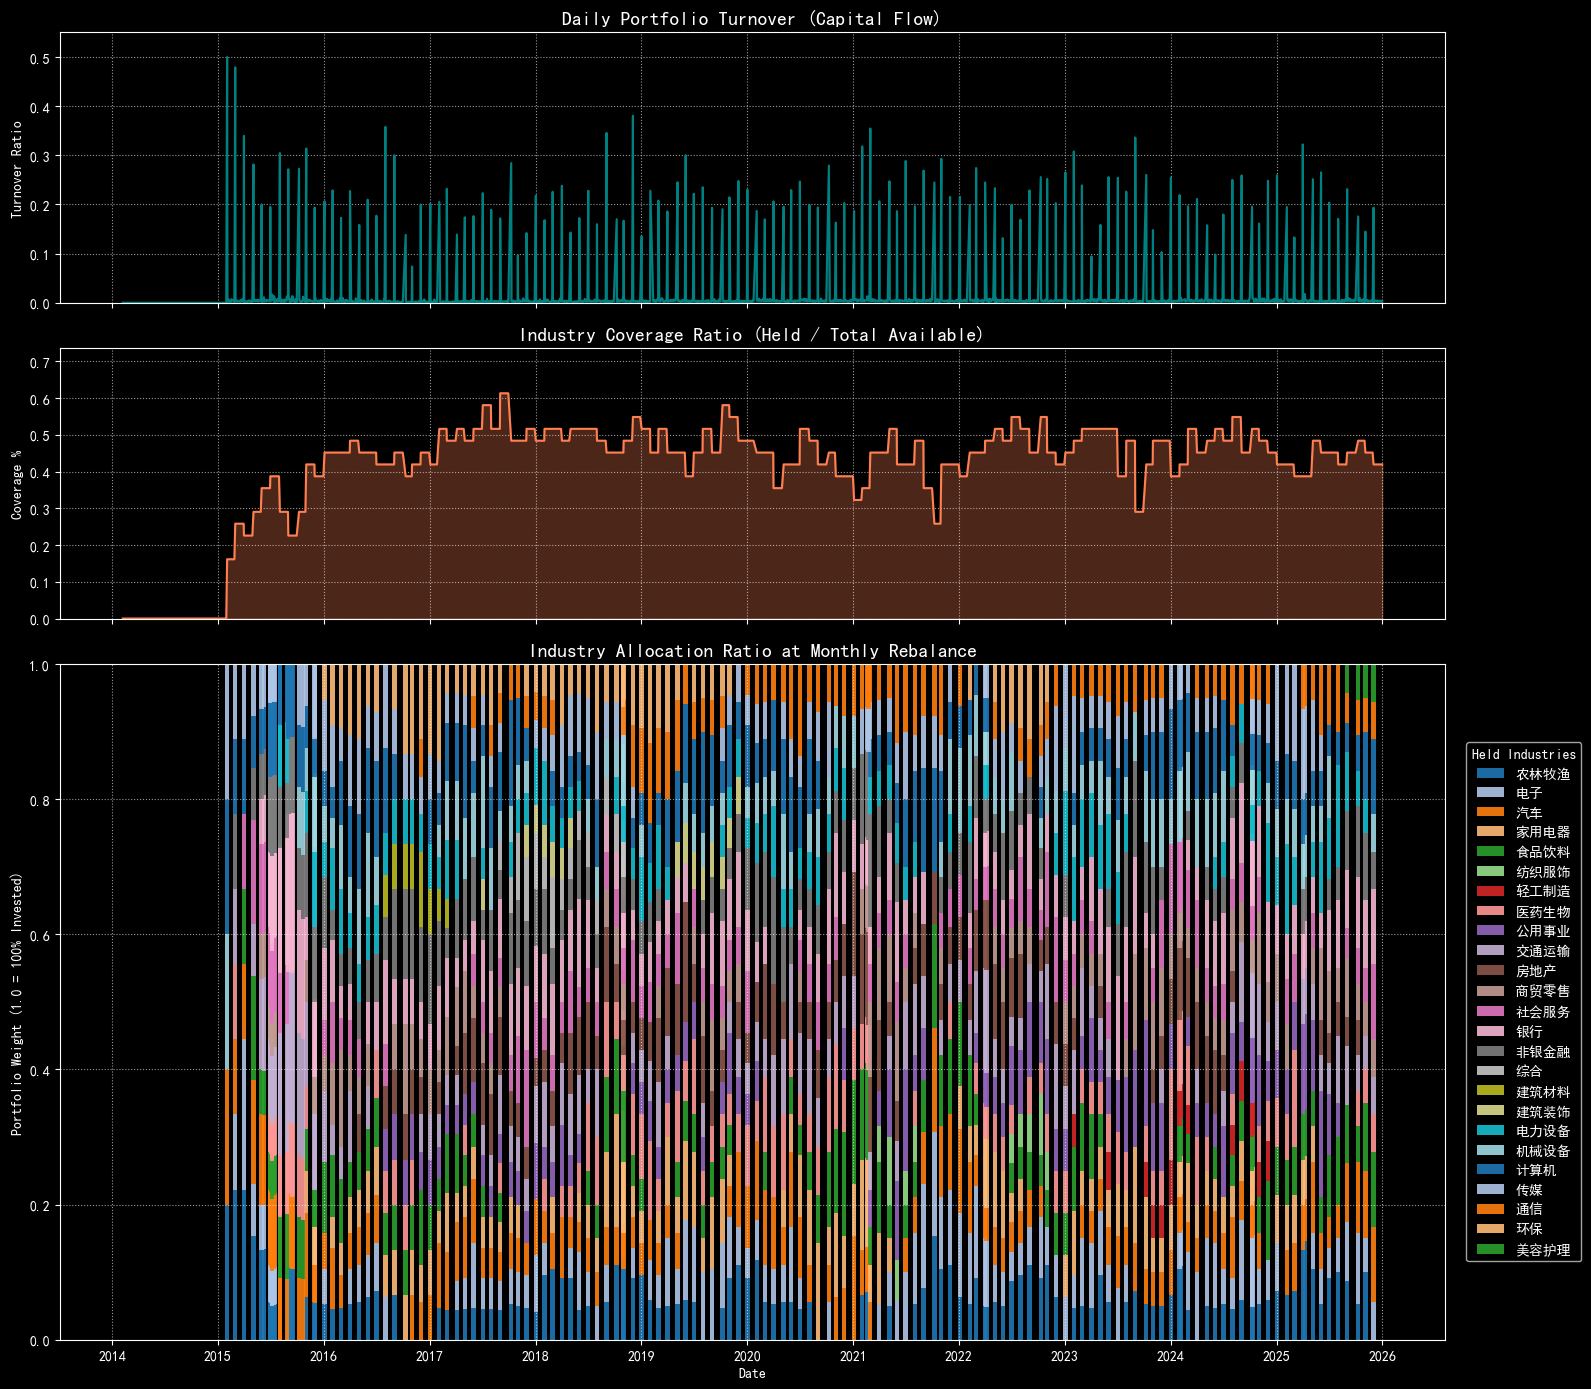

In [8]:
def plot_portfolio_dynamics(signal_weight):
    print("\n" + "="*20 + " GENERATING PORTFOLIO DYNAMICS CHARTS " + "="*20)
    
    # Ensure Chinese characters render correctly in the legend
    plt.rcParams["font.sans-serif"] = ["SimHei", "Arial Unicode MS"] # Fallbacks
    plt.rcParams["axes.unicode_minus"] = False 

    # 1. Calculate Daily Turnover
    weight_changes = signal_weight.diff().fillna(0.0)
    turnover = weight_changes.abs().sum(axis=1) / 2.0
    
    # 2. Calculate Industry Coverage Ratio
    # Count how many industries have a non-zero weight each day, divided by total industries
    active_industries = (signal_weight != 0).sum(axis=1)
    total_industries = len(signal_weight.columns)
    coverage_ratio = active_industries / total_industries
    
    # 3. Extract Portfolio Composition at Rebalance
    rebalance_days = turnover[turnover > 0.01].index
    
    if len(rebalance_days) == 0:
        print("No trades executed. Portfolio remained in cash.")
        return

    rebalance_weights = signal_weight.loc[rebalance_days]
    
    # Drop industries that were never held over the 10 years to keep the legend clean
    rebalance_weights = rebalance_weights.loc[:, (rebalance_weights != 0).any(axis=0)]

    # ===================== Plotting =====================
    # Expand to 3 subplots, allocating height appropriately
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 14), sharex=True, gridspec_kw={'height_ratios': [1, 1, 2.5]})
    
    # --- Plot 1 (Top): Turnover (Capital Flow) ---
    ax1.plot(turnover.index, turnover.values, color='teal', linewidth=1.5)
    ax1.fill_between(turnover.index, turnover.values, 0, color='teal', alpha=0.3)
    ax1.set_title('Daily Portfolio Turnover (Capital Flow)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Turnover Ratio')
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    max_turnover = turnover.max()
    ax1.set_ylim(0, max_turnover * 1.1)
    
    # --- Plot 2 (Middle): Industry Coverage Ratio ---
    ax2.plot(coverage_ratio.index, coverage_ratio.values, color='coral', linewidth=1.5)
    ax2.fill_between(coverage_ratio.index, coverage_ratio.values, 0, color='coral', alpha=0.3)
    ax2.set_title('Industry Coverage Ratio (Held / Total Available)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Coverage %')
    ax2.grid(True, linestyle=':', alpha=0.6)
    
    # Set y-axis to strictly bound between 0 (cash) and slightly above the max coverage
    ax2.set_ylim(0, coverage_ratio.max() * 1.2 if coverage_ratio.max() > 0 else 1.0)
    
    # --- Plot 3 (Bottom): Industry Allocation Ratio (Stacked Bar) ---
    bottom_array = np.zeros(len(rebalance_weights))
    cmap = plt.get_cmap('tab20')
    colors = [cmap(i % 20) for i in range(len(rebalance_weights.columns))]
    
    # Manually stack bars
    for i, column in enumerate(rebalance_weights.columns):
        ax3.bar(rebalance_weights.index, rebalance_weights[column], bottom=bottom_array, 
                width=15, color=colors[i], label=column, alpha=0.9)
        bottom_array += rebalance_weights[column].values
    
    ax3.set_title('Industry Allocation Ratio at Monthly Rebalance', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Portfolio Weight (1.0 = 100% Invested)')
    ax3.set_xlabel('Date')
    ax3.grid(True, linestyle=':', alpha=0.6)
    
    # Format the shared X-axis
    ax3.xaxis.set_major_locator(mdates.YearLocator())
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=0, ha='center')
    
    # Move the legend outside the plot
    ax3.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), title="Held Industries", fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Execute the visualization using your calculated weights
plot_portfolio_dynamics(signal_weight)

In institutional quantitative finance, keeping non-trading days (filled with 0.0 returns) in your final analytics suite creates a form of "statistical pollution." Removing them and using a pure trading-day index is the industry standard because it corrects significant distortions in risk calculations.

---

To verify if your alternative data factor possesses genuine Alpha, comparing it to a market-cap-weighted index like the CSI 300 can be deceptive. A cap-weighted index is heavily concentrated in a few massive mega-cap companies, whereas your strategy selects equal-weighted industry blocks. To create a mathematically fair baseline, you must construct an Equal-Weighted Industry Index. This represents the performance of a naive strategy that simply buys all industries in equal proportions every day.

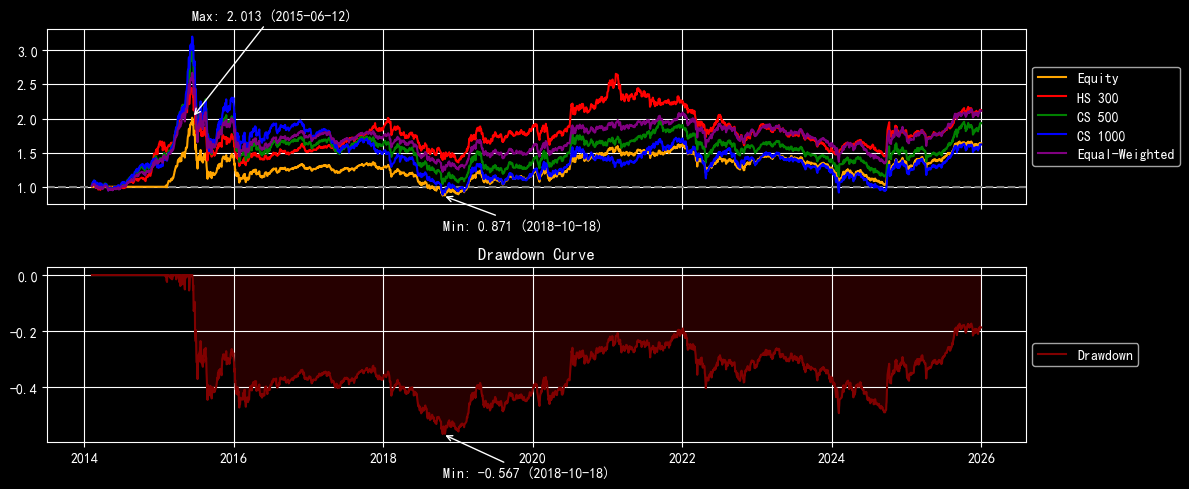

In [9]:
# Get benchmark return data
HS_300 = benchmark_roi_all_df["HS300"]
CS_500 = benchmark_roi_all_df["CSI500"]
CS_1000 = benchmark_roi_all_df["CSI1000"]

"""
We now have:
1. positions DataFrame: indicates whether we hold each stock on each day (1.0 for hold, 0.0 for not hold).
2. fee DataFrame: indicates the transaction fee incurred on each stock on each day (0.0 if no transaction, otherwise the fee rate).
3. weights DataFrame: indicates the weight of each stock in the portfolio on each day (equal weighted among held stocks).
These DataFrames can be used for backtesting the trading strategy.

Now we can calculate the daily portfolio returns based on the weights and price returns.
The daily portfolio return is calculated as the sum of the product of weights and price returns for all stocks.
"""
portfolio_gross_roi = (signal_weight * industry_level1_roi_all_df).sum(axis=1)
portfolio_total_fees = signal_fee.sum(axis=1)

# Net Portfolio Return
portfolio_net_roi = portfolio_gross_roi - portfolio_total_fees

# =====================================================================
# Calculate Raw Equal-Weighted Industry Returns
# =====================================================================
# Taking the mean across axis=1 averages all industry returns for each day
EW = industry_level1_roi_all_df.mean(axis=1)

# =====================================================================
# Align Timelines (Crucial for a Fair Comparison)
# =====================================================================
# Your strategy has a 12-month warmup period. The benchmark must start 
# at 1.0 on the exact same day your strategy executes its first trade.
strategy_start_date = portfolio_net_roi.index[0]
strategy_end_date = portfolio_net_roi.index[-1]

# Slice the benchmark to match the exact trading horizon of your strategy
ew_index_returns_filtered = EW.loc[strategy_start_date:strategy_end_date]
portfolio_returns_filtered = portfolio_net_roi.loc[strategy_start_date:strategy_end_date]

# Calculate Cumulative Equity Curves (Starting at 1.0)
ew_benchmark_equity = (1 + EW).cumprod()
cumulative_portfolio_return = (1 + portfolio_net_roi).cumprod()
cumulative_HS300_return = (1 + HS_300).cumprod()
cumulative_CS_500_return = (1 + CS_500).cumprod()
cumulative_CS_1000_return = (1 + CS_1000).cumprod()

plt.rcParams["axes.unicode_minus"] = False  # Display negative sign correctly
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

max_equity = max(cumulative_portfolio_return)
max_equity_date = cumulative_portfolio_return.idxmax().date()
min_equity = min(cumulative_portfolio_return)
min_equity_date = cumulative_portfolio_return.idxmin().date()
ax1.axhline(y=1, color="grey", linestyle="--")
ax1.plot(cumulative_portfolio_return, label="Equity", color="orange")
ax1.plot(cumulative_HS300_return.index, cumulative_HS300_return, label='HS 300', color="r")
ax1.plot(cumulative_CS_500_return.index, cumulative_CS_500_return, label='CS 500', color="g")
ax1.plot(cumulative_CS_1000_return.index, cumulative_CS_1000_return, label='CS 1000', color="b")
ax1.plot(ew_benchmark_equity.index, ew_benchmark_equity, label='Equal-Weighted', color="purple")
# ax1.set_title(f"Cumulative Returns: Portfolio vs Benchmarks")
ax1.legend(bbox_to_anchor=(1, 0.5), loc="center left")
# Annotate max value of equity
# xy is the point to annotate, xytext is the position of the text
# --- UPDATED: Annotate max value of equity ---
ax1.annotate(
    f'Max: {max_equity:.3f} ({max_equity_date})', 
    xy=(cumulative_portfolio_return.idxmax(), max_equity),
    xytext=(cumulative_portfolio_return.idxmax(), 1.05),   # 1.05 sets it exactly at title height
    textcoords=ax1.get_xaxis_transform(),                  # X uses dates, Y uses axis fractions
#     ha='center',                                           # Centers the text over the arrow
    arrowprops=dict(facecolor='black', arrowstyle='->')
)

# --- UPDATED: Annotate min value of equity ---
ax1.annotate(
    f'Min: {min_equity:.3f} ({min_equity_date})', 
    xy=(cumulative_portfolio_return.idxmin(), min_equity),
    xytext=(cumulative_portfolio_return.idxmin(), -0.15),  # -0.15 sets it slightly below the x-axis
    textcoords=ax1.get_xaxis_transform(),
#     ha='center',
    arrowprops=dict(facecolor='black', arrowstyle='->')
)
rolling_max = cumulative_portfolio_return.cummax()
drawdown = (cumulative_portfolio_return - rolling_max) / rolling_max
max_drawdown = min(drawdown)
max_drawdown_start = drawdown.idxmin().date()

ax2.plot(drawdown, label="Drawdown", color="maroon")
# Shade the area where drawdown is negative
ax2.fill_between(drawdown.index, 
                drawdown, 
                0, 
                where=drawdown < 0, 
                color='maroon', 
                alpha=0.3)
ax2.set_title("Drawdown Curve")
ax2.legend(bbox_to_anchor=(1, 0.5), loc="center left")
# Annotate min value of ax2
# --- UPDATED: Annotate min value of ax2 (Max Drawdown) ---
ax2.annotate(
    f'Min: {max_drawdown:.3f} ({max_drawdown_start})', 
    xy=(drawdown.idxmin(), max_drawdown),
    xytext=(drawdown.idxmin(), -0.2),                      # Puts text securely at the bottom of the subplot
    textcoords=ax2.get_xaxis_transform(),
#     ha='center',
    arrowprops=dict(facecolor='black', arrowstyle='->')
)
ax1.grid(True)
ax2.grid(True)
plt.tight_layout()
plt.show()

### Performance Metrics


==================== FACTOR ANALYSIS ====================


d:\anaconda3\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


IC Mean:          0.0024
ICIR:             0.0122
IC t-value:       0.6577
IC Winning Rate:  46.34%


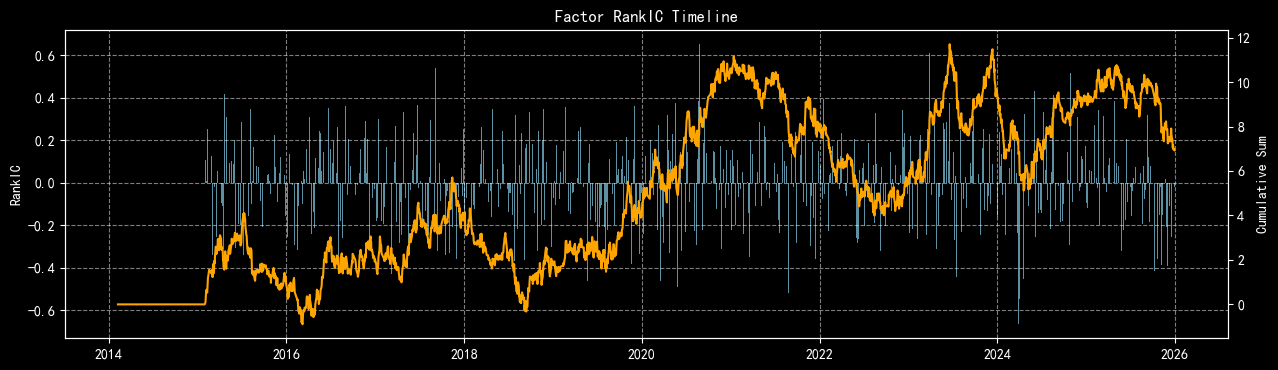

In [ ]:
# Ensure we use the proper risk-free rate assumption consistently across metrics
ANNUAL_RISK_FREE_RATE = 0.03  # 3% standard benchmark

# =====================================================================
# 1. FACTOR ANALYSIS ENGINE (IC, RankIC, ICIR, t-value)
# =====================================================================
print("\n" + "="*20 + " FACTOR ANALYSIS " + "="*20)

# Calculate Rank IC using the continuous factor score instead of truncated signals
IC_Series = signal_df.corrwith(industry_level1_roi_all_df, axis=1, method="spearman").fillna(0.0)

IC_mean = IC_Series.mean()
IC_std = IC_Series.std()
ICIR = IC_mean / IC_std if IC_std != 0 else 0.0
# FIXED: t-value multiplies by sqrt(N), does not divide
t_value = ICIR * np.sqrt(len(IC_Series)) if len(IC_Series) > 0 else 0.0
IC_winning_rate = sum(1 for ic in IC_Series if ic > 0) / len(IC_Series) if len(IC_Series) > 0 else 0.0

print(f"IC Mean:          {IC_mean:.4f}")
print(f"ICIR:             {ICIR:.4f}")
print(f"IC t-value:       {t_value:.4f}")
print(f"IC Winning Rate:  {IC_winning_rate:.2%}")

# Optional: Plot Factor IC Performance
fig_ic, ax_ic = plt.subplots(figsize=(15, 4))
ax_ic.bar(IC_Series.index, IC_Series.values, label='Daily RankIC', color='skyblue', alpha=0.7)
ax_ic_twin = ax_ic.twinx()
ax_ic_twin.plot(IC_Series.index, IC_Series.cumsum(), color='orange', label='Cumulative IC')
ax_ic.set_title('Factor RankIC Timeline')
ax_ic.set_ylabel('RankIC')
ax_ic_twin.set_ylabel('Cumulative Sum')
ax_ic.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# =====================================================================
# 2. PORTFOLIO PERFORMANCE METRICS (ROI, APY, Sharpe, Alpha, Beta)
# =====================================================================
print("\n" + "="*20 + " PERFORMANCE METRICS " + "="*20)

N_days = len(trading_days)

# Total Returns (ROI)
ROI = cumulative_portfolio_return.iloc[-1] - 1
HS_300_ROI = cumulative_HS300_return.iloc[-1] - 1
CS_500_ROI = cumulative_CS_500_return.iloc[-1] - 1
CS_1000_ROI = cumulative_CS_1000_return.iloc[-1] - 1
EW_ROI = ew_benchmark_equity.iloc[-1] - 1

# Annualized Returns (APY)
APY = (cumulative_portfolio_return.iloc[-1]) ** (252 / N_days) - 1
HS_300_APY = (cumulative_HS300_return.iloc[-1]) ** (252 / N_days) - 1
CS_500_APY = (cumulative_CS_500_return.iloc[-1]) ** (252 / N_days) - 1
CS_1000_APY = (cumulative_CS_1000_return.iloc[-1]) ** (252 / N_days) - 1
EW_APY = (ew_benchmark_equity.iloc[-1]) ** (252 / N_days) - 1

# Volatility (Annualized)
Asset_Annual_Volatility = portfolio_net_roi.std() * np.sqrt(252)
HS_300_Annual_Volatility = HS_300.std() * np.sqrt(252)
CS_500_Annual_Volatility = CS_500.std() * np.sqrt(252)
CS_1000_Annual_Volatility = CS_1000.std() * np.sqrt(252)
EW_Annual_Volatility = ew_benchmark_equity.std() * np.sqrt(252)

# Sharpe Ratio (Using Daily Arithmetic Returns for standard institutional representation)
sharpe_ratio = (portfolio_net_roi.mean() / portfolio_net_roi.std()) * np.sqrt(252) if portfolio_net_roi.std() != 0 else 0.0
HS_300_sharpe_ratio = (HS_300.mean() / HS_300.std()) * np.sqrt(252) if HS_300.std() != 0 else 0.0
CS_500_sharpe_ratio = (CS_500.mean() / CS_500.std()) * np.sqrt(252) if CS_500.std() != 0 else 0.0
CS_1000_sharpe_ratio = (CS_1000.mean() / CS_1000.std()) * np.sqrt(252) if CS_1000.std() != 0 else 0.0
EW_sharpe_ratio = (EW.mean() / EW.std()) * np.sqrt(252) if EW.std() != 0 else 0.0

# FIXED: Calculate Beta and Alpha using daily ROIs, not cumulative equity paths
Beta = portfolio_net_roi.cov(HS_300) / HS_300.var() if HS_300.var() != 0 else 1.0
Alpha = APY - (ANNUAL_RISK_FREE_RATE + Beta * (HS_300_APY - ANNUAL_RISK_FREE_RATE))

print(f"{'Metric':<20} | {'Portfolio':<10} | {'HS300':<10} | {'CSI500':<10} | {'CSI1000':<10} | {'Equal-Weighted':<15}")
print("-" * 85)
print(f"{'Total ROI':<20} | {ROI:.2%} | {HS_300_ROI:.2%} | {CS_500_ROI:.2%} | {CS_1000_ROI:.2%} | {EW_ROI:.2%}")
print(f"{'Annualized APY':<20} | {APY:.2%} | {HS_300_APY:.2%} | {CS_500_APY:.2%} | {CS_1000_APY:.2%} | {EW_APY:.2%}")
print(f"{'Annual Volatility':<20} | {Asset_Annual_Volatility:.2%} | {HS_300_Annual_Volatility:.2%} | {CS_500_Annual_Volatility:.2%} | {CS_1000_Annual_Volatility:.2%} | {EW_Annual_Volatility:.2%}")
print(f"{'Sharpe Ratio':<20} | {sharpe_ratio:.4f} | {HS_300_sharpe_ratio:.4f} | {CS_500_sharpe_ratio:.4f} | {CS_1000_sharpe_ratio:.4f} | {EW_sharpe_ratio:.4f}")
print("-" * 65)
print(f"Portfolio Beta (vs HS300): {Beta:.2f}")
print(f"Portfolio Alpha (Annual):  {Alpha:.2%}")


==================== PERFORMANCE METRICS ====================
Metric               | Portfolio  | HS300      | CSI500     | CSI1000    | Equal-Weighted 
-------------------------------------------------------------------------------------
Total ROI            | 50.74% | 111.67% | 93.16% | 61.99% | 111.25%
Annualized APY       | 3.63% | 6.74% | 5.89% | 4.28% | 6.72%
Annual Volatility    | 21.16% | 21.51% | 24.96% | 27.18% | 411.41%
Sharpe Ratio         | 0.2752 | 0.4113 | 0.3552 | 0.2914 | 0.4161
-----------------------------------------------------------------
Portfolio Beta (vs HS300): 0.85
Portfolio Alpha (Annual):  -2.56%
